# Notebook 02 — Nettoyage des 3 sources de données (affichage des résultats)

> ⚠️ **Ce notebook ne calcule plus rien.** Depuis la réorganisation du projet, tout le
> calcul est fait par le script `scripts/etape02_nettoyage_donnees.py`, à lancer **à la main**, depuis la racine du
> projet :
>
> ```bash
> python scripts/etape02_nettoyage_donnees.py
> ```
>
> Ce notebook se contente de **lire et afficher** ce que ce script a produit : les gros
> fichiers de sortie (chemins dans `config.py`) et le rapport d'exécution `02_nettoyage`
> (`outputs/rapports/`, voir `rapports.py`), qui contient tous les compteurs et petits
> tableaux de diagnostic autrefois imprimés au fil des cellules.
>
> Il est donc **léger et ré-exécutable à volonté** (`Run All` en quelques secondes), sans
> jamais relancer un calcul. Si tu changes un paramètre dans `config.py`, relance d'abord
> le script, puis ce notebook.


**Ce que le script a fait**, en 3 parties indépendantes (aucune ne lit le résultat d'une
autre) :

- **Partie A — Caractéristiques** (`datashare.parquet`) : période de départ, filtre
  automatique des caractéristiques trop incomplètes, nettoyage du secteur (`sic2`)
  → `data/interim/characteristics_clean.parquet` + `caracteristiques_retenues.json`
- **Partie B — Rendements** (`StockReturn.parquet`) : conversion des codes CRSP non
  numériques, suppression des rendements manquants (jamais imputés, c'est la cible)
  → `data/interim/returns_clean.parquet`
- **Partie C — Macro** (`MacroData.parquet`) : restriction à la période utile,
  construction des 8 prédicteurs macro de GKX
  → `data/interim/macro_clean.parquet`

## 0. Import et chargement du rapport d'exécution

In [1]:
import sys
sys.path.append("..")  # config.py, rapports.py sont a la racine du projet

import pandas as pd
import matplotlib.pyplot as plt

import config
import rapports

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

# Leve une erreur explicite (avec la commande a lancer) si le script n'a jamais tourne.
rap = rapports.charger('02_nettoyage')
print(rap.resume())

Rapport '02_nettoyage' produit le 2026-08-15T00:49:41


## Partie A — Caractéristiques (`datashare.parquet`)

### A.1 / A.2 Point de départ et choix de la période

Beaucoup de caractéristiques comptables ne sont fiables qu'à partir des années 1970-1980
(couverture Compustat plus complète) : démarrer en 1957 comme GKX ajouterait surtout des
lignes très incomplètes. Le tableau ci-dessous montre le taux moyen de valeurs manquantes
par décennie, qui motive le choix de `ANNEE_DEBUT`.

👉 **Pour ajuster la valeur**, modifie `ANNEE_DEBUT` dans `config.py`, puis relance le
script (la partie C utilisera automatiquement la même valeur).

In [2]:
print("Dimensions de depart :", tuple(rap.valeur('A_shape_depart')))
print()
print("Taux moyen de valeurs manquantes par decennie (%) :")
display(rap.table('A_missing_par_decennie'))

print(f"ANNEE_DEBUT (config.py) : {rap.valeur('A_annee_debut')}")
print("Dimensions apres filtre sur l'annee :", tuple(rap.valeur('A_shape_apres_filtre_annee')))
rap.table('A_apercu_brut')

Dimensions de depart : (4117300, 97)

Taux moyen de valeurs manquantes par decennie (%) :


,taux_missing_moyen
decennie,
1950,79.0
1960,63.2
1970,38.9
1980,32.2
1990,26.7
2000,20.9
2010,21.8
2020,33.3


ANNEE_DEBUT (config.py) : 1980
Dimensions apres filtre sur l'annee : (3344804, 99)


,permno,DATE,mvel1,beta,betasq,chmom,dolvol,idiovol,indmom,mom1m,...,stdcf,ms,baspread,ill,maxret,retvol,std_dolvol,std_turn,zerotrade,sic2
0,10006,19570131,82249.000,1.122846,1.260784,0.047180,9.569953,0.025742,0.046433,0.044843,...,NaN,NaN,0.013234,9.411565e-08,0.015453,0.008058,0.355638,0.460420,1.120996e-07,37.0
1,10014,19570131,3903.375,0.426734,0.182102,-0.275641,6.237836,0.072103,0.046433,-0.086957,...,NaN,NaN,0.033305,6.610609e-06,0.047619,0.033495,1.152126,1.169610,9.229146e-08,NaN
2,10022,19570131,9273.250,1.066449,1.137313,-0.025490,7.008844,0.027648,0.046433,-0.060377,...,NaN,NaN,0.016023,2.286832e-06,0.020833,0.015589,0.815777,0.679803,1.181757e-07,NaN
3,10030,19570131,54465.875,0.926038,0.857547,0.018171,9.825337,0.021700,0.046433,0.044633,...,NaN,NaN,0.015295,1.464273e-07,0.039326,0.015849,0.739302,1.333656,6.126699e-08,NaN
4,10057,19570131,40250.000,1.247748,1.556875,0.025785,7.901007,0.025506,0.046433,0.086667,...,NaN,NaN,0.005954,1.380375e-06,0.056856,0.019945,0.755510,0.410391,3.315790e+00,NaN


### A.3 / A.3bis L'univers candidat et le filtre de valeurs manquantes

`config.CARACTERISTIQUES` liste les 94 noms de colonnes de `datashare.parquet` (l'univers
**candidat**). Le script en retient automatiquement un **sous-ensemble** : il calcule le
taux de valeurs manquantes de chacune sur `annee >= ANNEE_DEBUT` et exclut celles au-dessus
de `config.SEUIL_MAX_PCT_MANQUANT_CARACTERISTIQUES`.

La liste retenue est sauvegardée dans `data/interim/caracteristiques_retenues.json` —
c'est ce fichier que lisent ensuite automatiquement l'étape 03 et les modèles 04 à 06
(via `config.CARACTERISTIQUES_RETENUES`), sans rien recopier à la main.

In [3]:
candidates = rap.valeur('A_caracteristiques_candidates')
gardees = rap.valeur('A_caracteristiques_gardees')
exclues = rap.valeur('A_caracteristiques_exclues')
seuil = rap.valeur('A_seuil_missing')

print(f"Univers candidat : {len(candidates)} caracteristiques")
introuvables = rap.valeur('A_colonnes_introuvables')
print("Colonnes introuvables dans le fichier :", introuvables if introuvables else "aucune (OK)")
print()
print(f"Seuil d'exclusion : {seuil*100:.0f}% de valeurs manquantes")
print(f"Caracteristiques RETENUES : {len(gardees)} / {len(candidates)}")
print()
if exclues:
    taux = rap.table('A_taux_missing')['pct_manquant']
    print("Caracteristiques EXCLUES (trop incompletes) :")
    for c in exclues:
        print(f"  - {c:<18s} {taux[c]:5.1f}% manquant")
else:
    print("Aucune caracteristique exclue : toutes les candidates passent le seuil.")

Univers candidat : 30 caracteristiques
Colonnes introuvables dans le fichier : aucune (OK)

Seuil d'exclusion : 35% de valeurs manquantes
Caracteristiques RETENUES : 30 / 30

Aucune caracteristique exclue : toutes les candidates passent le seuil.


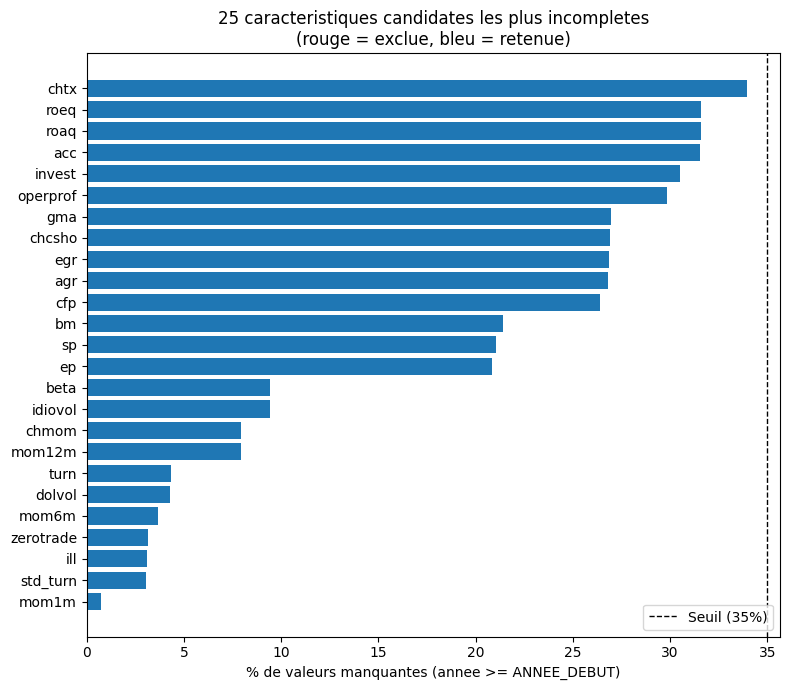

In [4]:
# Les 25 candidates les plus incompletes, avec le seuil d'exclusion en repere
taux = rap.table('A_taux_missing')['pct_manquant']
top_missing = taux.sort_values(ascending=False).head(25).sort_values()
couleurs = ['tab:red' if v > seuil * 100 else 'tab:blue' for v in top_missing]

fig, ax = plt.subplots(figsize=(8, max(4, 0.28 * len(top_missing))))
ax.barh(top_missing.index, top_missing.values, color=couleurs)
ax.axvline(seuil * 100, color='black', linewidth=1, linestyle='--',
           label=f"Seuil ({seuil*100:.0f}%)")
ax.set_xlabel("% de valeurs manquantes (annee >= ANNEE_DEBUT)")
ax.set_title("25 caracteristiques candidates les plus incompletes\n(rouge = exclue, bleu = retenue)")
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### A.4 / A.5 Valeurs manquantes restantes et secteur

Les valeurs manquantes résiduelles ne sont **pas** imputées ici : c'est volontaire, elles
le seront à l'étape 03 (partie B), une fois l'univers investissable filtré, pour que la
médiane utilisée vienne de la population réellement modélisée.

`sic2` est transformé en catégorie texte, avec une catégorie explicite `"Inconnu"` plutôt
que d'exclure les entreprises sans secteur renseigné.

In [5]:
print("Dimensions apres reduction des colonnes :", tuple(rap.valeur('A_shape_apres_reduction')))
print()
print("Valeurs manquantes restantes (% des lignes, imputees a l'etape 03) :")
manquants = rap.table('A_missing_restant_pct')
display(manquants if len(manquants) else "Aucune valeur manquante restante.")

print("Repartition des secteurs (top 10) :")
display(rap.table('A_repartition_secteurs'))

Dimensions apres reduction des colonnes : (3344804, 34)

Valeurs manquantes restantes (% des lignes, imputees a l'etape 03) :


,pct_manquant
chtx,33.96
roeq,31.57
roaq,31.57
acc,31.56
invest,30.49
operprof,29.85
gma,26.94
chcsho,26.90
egr,26.86
agr,26.79


Repartition des secteurs (top 10) :


,nb_lignes
secteur,
67,393396
60,291885
73,268500
28,227216
36,190468
38,152757
35,148856
Inconnu,123948
13,116220


### A.6 Résultat final de la partie A

In [6]:
print("Dimensions finales :", tuple(rap.valeur('A_shape_finale')))
print("Colonnes finales   :", rap.valeur('A_colonnes_finales'))
print()
print("Valeurs manquantes restantes par colonne :")
display(rap.table('A_missing_final'))
print("Fichier ecrit par le script :", config.FICHIER_CARACTERISTIQUES_CLEAN)

Dimensions finales : (3344804, 34)
Colonnes finales   : ['permno', 'DATE', 'annee', 'mom1m', 'mom6m', 'mom12m', 'chmom', 'indmom', 'maxret', 'mvel1', 'dolvol', 'turn', 'std_turn', 'ill', 'zerotrade', 'baspread', 'retvol', 'idiovol', 'beta', 'bm', 'ep', 'sp', 'cfp', 'agr', 'chcsho', 'egr', 'invest', 'gma', 'operprof', 'roaq', 'roeq', 'acc', 'chtx', 'secteur']

Valeurs manquantes restantes par colonne :


,nb_manquant
permno,0
DATE,0
annee,0
mom1m,24788
mom6m,122940
mom12m,265826
chmom,265826
indmom,9
maxret,216
mvel1,1165


Fichier ecrit par le script : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\data\interim\characteristics_clean.parquet


In [7]:
rap.table('A_describe')

,count,mean,std,min,25%,50%,75%,max
permno,3344804.0,6.018914e+04,2.822724e+04,1.000000e+04,3.351600e+04,7.527200e+04,8.363100e+04,9.343600e+04
DATE,3344804.0,2.000220e+07,1.148780e+05,1.980013e+07,1.991043e+07,1.999123e+07,2.009123e+07,2.021123e+07
annee,3344804.0,2.000152e+03,1.148784e+01,1.980000e+03,1.991000e+03,1.999000e+03,2.009000e+03,2.021000e+03
mom1m,3320016.0,8.698103e-03,1.514649e-01,-7.365891e-01,-6.148862e-02,0.000000e+00,6.631580e-02,2.000000e+00
mom6m,3221864.0,4.830844e-02,3.633657e-01,-9.132948e-01,-1.384615e-01,2.237773e-02,1.800000e-01,7.533333e+00
mom12m,3078978.0,1.185805e-01,5.881339e-01,-9.741036e-01,-2.000000e-01,5.128205e-02,3.058407e-01,1.129612e+01
chmom,3078978.0,-1.111127e-03,5.564749e-01,-8.461765e+00,-2.420401e-01,-7.173381e-03,2.310009e-01,7.783077e+00
indmom,3344795.0,1.318307e-01,2.837798e-01,-7.595030e-01,-3.416476e-02,1.000874e-01,2.513564e-01,2.748655e+00
maxret,3344588.0,7.211179e-02,7.438007e-02,0.000000e+00,2.777778e-02,4.929578e-02,8.823530e-02,9.666665e-01
mvel1,3343639.0,2.159091e+06,1.578347e+07,0.000000e+00,3.094775e+04,1.359149e+05,6.584343e+05,2.711977e+09


In [8]:
rap.table('A_apercu_final')

,permno,DATE,annee,mom1m,mom6m,mom12m,chmom,indmom,maxret,mvel1,...,chcsho,egr,invest,gma,operprof,roaq,roeq,acc,chtx,secteur
772496,10006,19800131,1980,0.000000,0.001976,0.188961,-1.846415e-01,0.186399,0.025180,303420.750,...,0.003092,0.081198,0.175147,0.263644,0.236314,0.012501,0.037021,0.113203,0.000978,37
772497,10057,19800131,1980,0.174157,0.100922,0.257713,1.502377e-01,0.378289,0.063158,111423.125,...,0.003628,0.116337,0.012352,0.463597,0.296707,0.029629,0.058793,0.084369,0.012542,36
772498,10058,19800131,1980,0.111111,0.285714,0.125000,5.535714e-01,0.323635,0.111111,3127.500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36
772499,10065,19800131,1980,0.009901,0.132784,0.244092,4.574012e-02,0.323635,0.070000,199206.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Inconnu
772500,10103,19800131,1980,0.500000,-0.333333,-0.333333,-1.686023e-08,0.278190,0.250000,2043.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33


## Partie B — Rendements (`StockReturn.parquet`)

### B.1 à B.3 Codes CRSP non numériques

La colonne `RET` de CRSP mélange des rendements numériques et des **codes texte spéciaux**
indiquant une raison précise pour laquelle le rendement est manquant (pas de cotation,
donnée insuffisante, société retirée de la cote...). Dans tous les cas, ces lignes n'ont
pas de rendement utilisable : le script les convertit en `NaN`.

In [9]:
print("Dimensions de depart :", tuple(rap.valeur('B_shape_depart')))
print("Type de la colonne RET :", rap.valeur('B_dtype_ret_depart'))
print()
print("Codes non numeriques trouves dans RET :")
display(rap.table('B_codes_speciaux'))
print(f"{rap.valeur('B_nb_codes_speciaux')} lignes ({rap.valeur('B_pct_codes_speciaux'):.2f} %)")
print()
print(f"% de RET manquant apres conversion : {rap.valeur('B_pct_manquant_apres_conversion'):.2f} %")

Dimensions de depart : (4859751, 3)
Type de la colonne RET : str

Codes non numeriques trouves dans RET :


,nb_lignes
RET,
B,65232
C,39204


104436 lignes (2.15 %)

% de RET manquant apres conversion : 3.91 %


### B.4 Rendements manquants : supprimés, jamais imputés

**Règle importante, différente de la partie A :** on n'impute jamais la variable cible.
Remplacer un rendement manquant par une médiane reviendrait à *inventer* la donnée qu'on
cherche justement à prédire — une fuite de données qui fausserait complètement
l'évaluation du modèle. La seule option raisonnable est de **retirer** ces lignes.

In [10]:
print(f"Lignes avant suppression : {rap.valeur('B_lignes_avant_dropna')}")
print(f"Lignes apres suppression : {rap.valeur('B_lignes_apres_dropna')}")
print(f"Lignes supprimees : {rap.valeur('B_pct_lignes_supprimees'):.2f} %")

Lignes avant suppression : 4859751
Lignes apres suppression : 4669780
Lignes supprimees : 3.91 %


### B.5 Valeurs extrêmes (diagnostic uniquement)

Un rendement mensuel de +500 % ou -95 % est rare mais **pas forcément une erreur** (delisting,
fusion, action très volatile). Le script se contente donc de les repérer, sans rien supprimer.

In [11]:
print("Statistiques descriptives de RET :")
display(rap.table('B_describe_ret'))
print("Quantiles extremes :")
display(rap.table('B_quantiles_ret'))

seuil_ex = rap.valeur('B_seuil_extreme')
print(f"Rendements > +{seuil_ex*100:.0f}% : {rap.valeur('B_nb_extremes_hauts')} lignes")
print(f"Rendements < -95%   : {rap.valeur('B_nb_extremes_bas')} lignes")

Statistiques descriptives de RET :


,RET
count,4.669780e+06
mean,1.002258e-02
std,1.744961e-01
min,-9.958300e-01
25%,-5.816600e-02
50%,0.000000e+00
75%,6.185600e-02
max,3.900000e+01


Quantiles extremes :


,RET
0.001,-0.636447
0.010,-0.380952
0.500,0.000000
0.990,0.541667
0.999,1.400000


Rendements > +500% : 155 lignes
Rendements < -95%   : 30 lignes


### B.6 / B.7 Harmonisation et résultat final de la partie B

In [12]:
doublons = rap.valeur('B_doublons_permno_mois')
print(f"Doublons (permno, annee_mois) : {doublons}")
if doublons > 0:
    print("ATTENTION : a investiguer avant la fusion (etape 03, partie A).")
print()
print("Dimensions finales :", tuple(rap.valeur('B_shape_finale')))
print("Colonnes finales   :", rap.valeur('B_colonnes_finales'))
print("Periode couverte   : de", rap.valeur('B_periode')[0], "a", rap.valeur('B_periode')[1])
display(rap.table('B_missing_final'))
rap.table('B_apercu_final')

Doublons (permno, annee_mois) : 0

Dimensions finales : (4669780, 3)
Colonnes finales   : ['permno', 'annee_mois', 'RET']
Periode couverte   : de 195601 a 202412


,nb_manquant
permno,0
annee_mois,0
RET,0


,permno,annee_mois,RET
2,10000,198602,-0.257143
3,10000,198603,0.365385
4,10000,198604,-0.098592
5,10000,198605,-0.222656
6,10000,198606,-0.005025


## Partie C — Variables macro (`MacroData.parquet`)

### C.1 à C.3 Conversion numérique et comblement des trous

Les fichiers Welch & Goyal contiennent souvent de grands nombres formatés avec une virgule
comme séparateur de milliers (ex: `"4,796.56"`), que pandas ne convertit pas automatiquement :
le script force la conversion après avoir retiré les virgules.

Contrairement aux caractéristiques d'entreprises, il n'y a qu'**une seule ligne par mois**
ici : pas de médiane croisée possible. Le comblement se fait donc par **dernière valeur
connue** (`ffill`, standard pour des séries macro qui évoluent lentement), avec un `bfill`
en secours pour un éventuel trou en tout début de période.

In [13]:
print("Dimensions de depart :", tuple(rap.valeur('C_shape_depart')))
print("Colonnes :", rap.valeur('C_colonnes_depart'))
print("Periode couverte (yyyymm) :", rap.valeur('C_periode_depart'))
print()
print("Types apres conversion numerique forcee :")
display(rap.table('C_dtypes_apres_conversion'))
print("Dimensions apres filtre sur l'annee :", tuple(rap.valeur('C_shape_apres_filtre_annee')))

Dimensions de depart : (1860, 18)
Colonnes : ['yyyymm', 'Index', 'D12', 'E12', 'b/m', 'tbl', 'AAA', 'BAA', 'lty', 'ntis', 'Rfree', 'infl', 'ltr', 'corpr', 'svar', 'csp', 'CRSP_SPvw', 'CRSP_SPvwx']
Periode couverte (yyyymm) : [187101, 202512]

Types apres conversion numerique forcee :


,dtype
yyyymm,int64
Index,float64
D12,float64
E12,float64
b/m,float64
tbl,float64
AAA,float64
BAA,float64
lty,float64
ntis,float64


Dimensions apres filtre sur l'annee : (552, 19)


In [14]:
print("% de valeurs manquantes par colonne AVANT comblement :")
display(rap.table('C_missing_avant_comblement'))

vides = rap.valeur('C_colonnes_entierement_vides')
if vides:
    print("ATTENTION - colonnes ENTIEREMENT vides sur la periode choisie :", vides)
    print("-> soit tu avances ANNEE_DEBUT, soit tu ne pourras pas utiliser ces colonnes.")
else:
    print("Comblement OK : aucune colonne entierement vide.")

% de valeurs manquantes par colonne AVANT comblement :


,pct_manquant
csp,50.0
Index,0.0
D12,0.0
b/m,0.0
E12,0.0
AAA,0.0
BAA,0.0
lty,0.0
tbl,0.0
ntis,0.0


Comblement OK : aucune colonne entierement vide.


### C.4 Les 8 prédicteurs macro de Gu, Kelly & Xiu (2020)

| Prédicteur | Colonne finale | Calcul |
|---|---|---|
| `dp` | `macro_dp` | `log(D12) - log(Index)` |
| `ep` | `macro_ep` | `log(E12) - log(Index)` |
| `bm` | `macro_bm` | colonne `b/m` |
| `ntis` | `macro_ntis` | colonne `ntis` |
| `tbl` | `macro_tbl` | colonne `tbl` |
| `tms` | `macro_tms` | `lty - tbl` |
| `dfy` | `macro_dfy` | `BAA - AAA` |
| `svar` | `macro_svar` | colonne `svar` |

⚠️ **Pourquoi le préfixe `macro_` ?** Les caractéristiques d'entreprise de la partie A
contiennent déjà des colonnes `bm` et `ep`. Sans préfixe, la fusion de l'étape 03
renommerait silencieusement les deux versions en `bm_x` / `bm_y` — un piège classique.

In [15]:
print("Valeurs <= 0 dans les colonnes passees au log (le log y serait NaN) :")
print(rap.valeur('C_valeurs_non_positives'))
print()
display(rap.table('C_apercu_predicteurs'))
print("Valeurs manquantes dans les 8 predicteurs GKX :")
display(rap.table('C_missing_predicteurs_gkx'))

Valeurs <= 0 dans les colonnes passees au log (le log y serait NaN) :
{'Index': 0, 'D12': 0, 'E12': 0}



,macro_dp,macro_ep,macro_bm,macro_ntis,macro_tbl,macro_tms,macro_dfy,macro_svar
1308,-2.997135,-2.029331,1.016955,0.011297,0.1200,-0.0086,0.0133,0.001906
1309,-2.984012,-2.015429,1.031930,0.010827,0.1286,-0.0100,0.0119,0.001898
1310,-2.867997,-1.898656,1.093732,0.011877,0.1520,-0.0281,0.0149,0.004622
1311,-2.900294,-1.946634,1.051820,0.015348,0.1320,-0.0244,0.0215,0.002746
1312,-2.937874,-1.999867,1.010049,0.015052,0.0858,0.0179,0.0218,0.001510


Valeurs manquantes dans les 8 predicteurs GKX :


,nb_manquant
macro_dp,0
macro_ep,0
macro_bm,0
macro_ntis,0
macro_tbl,0
macro_tms,0
macro_dfy,0
macro_svar,0


### C.5 / C.6 Résultat final de la partie C

`Rfree` est conservé séparément (ce n'est pas un prédicteur, mais l'étape 03 en a besoin
pour calculer le rendement excédentaire `excess_return = RET - Rfree`).

In [16]:
print("Dimensions finales :", tuple(rap.valeur('C_shape_finale')))
print("Colonnes finales   :", rap.valeur('C_colonnes_finales'))
print()
print("Valeurs manquantes restantes :")
display(rap.table('C_missing_final'))
rap.table('C_apercu_final')

Dimensions finales : (552, 10)
Colonnes finales   : ['annee_mois', 'macro_dp', 'macro_ep', 'macro_bm', 'macro_ntis', 'macro_tbl', 'macro_tms', 'macro_dfy', 'macro_svar', 'Rfree']

Valeurs manquantes restantes :


,nb_manquant
annee_mois,0
macro_dp,0
macro_ep,0
macro_bm,0
macro_ntis,0
macro_tbl,0
macro_tms,0
macro_dfy,0
macro_svar,0
Rfree,0


,annee_mois,macro_dp,macro_ep,macro_bm,macro_ntis,macro_tbl,macro_tms,macro_dfy,macro_svar,Rfree
1308,198001,-2.997135,-2.029331,1.016955,0.011297,0.1200,-0.0086,0.0133,0.001906,0.0080
1309,198002,-2.984012,-2.015429,1.031930,0.010827,0.1286,-0.0100,0.0119,0.001898,0.0089
1310,198003,-2.867997,-1.898656,1.093732,0.011877,0.1520,-0.0281,0.0149,0.004622,0.0121
1311,198004,-2.900294,-1.946634,1.051820,0.015348,0.1320,-0.0244,0.0215,0.002746,0.0126
1312,198005,-2.937874,-1.999867,1.010049,0.015052,0.0858,0.0179,0.0218,0.001510,0.0081


## Résumé global

Les 3 fichiers nettoyés sont dans `data/interim/` :

- `characteristics_clean.parquet` (Partie A) — peut encore contenir des valeurs manquantes
  (volontaire, imputées à l'étape 03)
- `returns_clean.parquet` (Partie B) — plus aucune valeur manquante dans `RET`
  (lignes supprimées, jamais imputées)
- `macro_clean.parquet` (Partie C) — plus aucune valeur manquante (`ffill`/`bfill`)

**Étape suivante :** `python scripts/etape03_construction_panel.py`, puis
`03_construction_panel.ipynb` pour en visualiser le résultat.